In [4]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

In [5]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


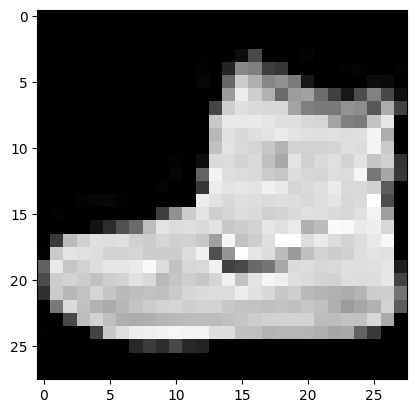

In [7]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap='gray')
plt.show()

In [8]:
print(y_train[0])

9


In [9]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [10]:
print(x_train.min())
print(x_train.max())

0.0
1.0


In [11]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape)

(60000, 28, 28, 1)


In [12]:
from tensorflow.keras import models, layers

model = models.Sequential()

model.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(28,28,1)
))

model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(
    64,
    activation='relu'
))

model.add(layers.Dense(
    10,
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.8222 - loss: 0.4899 - val_accuracy: 0.8718 - val_loss: 0.3626
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.8800 - loss: 0.3297 - val_accuracy: 0.8727 - val_loss: 0.3540
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.8984 - loss: 0.2808 - val_accuracy: 0.8837 - val_loss: 0.3125
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - accuracy: 0.9094 - loss: 0.2466 - val_accuracy: 0.8912 - val_loss: 0.2846
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 84s 27ms/step - accuracy: 0.9179 - loss: 0.2215 - val_accuracy: 0.9083 - val_loss: 0.2499
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 80s 26ms/step - accuracy: 0.9252 - loss: 0.2003 - val_accuracy: 0.9100 - val_loss: 0.2463
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.9320 - loss: 0.1798 - val_accuracy: 0.9072 - val_loss: 0.2549
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - accuracy: 0.9388 -

In [16]:
test_loss, test_acc = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy =", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9078 - loss: 0.2935
Test Accuracy = 0.907800018787384


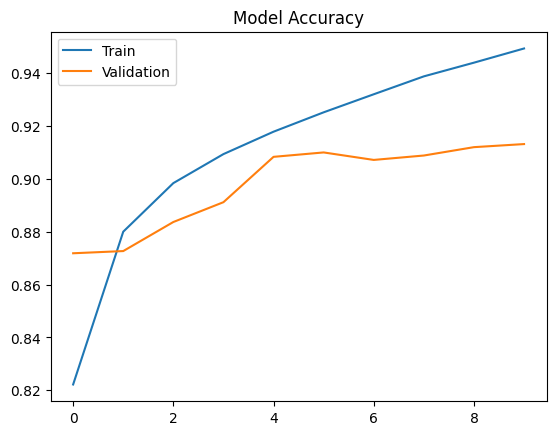

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Model Accuracy')
plt.show()

In [18]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

In [21]:
history = model.fit(
    x_train,
    y_train,
    epochs=15,
    validation_split=0.1,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 29ms/step - accuracy: 0.9680 - loss: 0.0881 - val_accuracy: 0.9180 - val_loss: 0.2747 - learning_rate: 5.0000e-04
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 79s 27ms/step - accuracy: 0.9718 - loss: 0.0762 - val_accuracy: 0.9167 - val_loss: 0.2848 - learning_rate: 5.0000e-04
Epoch 3/15
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9768 - loss: 0.0638
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.9754 - loss: 0.0676 - val_accuracy: 0.9145 - val_loss: 0.2855 - learning_rate: 5.0000e-04
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - accuracy: 0.9833 - loss: 0.0500 - val_accuracy: 0.9200 - val_loss: 0.2969 - learning_rate: 2.5000e-04
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 27ms/step - accuracy: 0.9854 - loss: 0.0450 - val_accuracy: 0.9172 - val_loss: 0.3094 - learning_rate: 2.5000e-04


In [22]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1000
           1       1.00      0.97      0.99      1000
           2       0.85      0.88      0.87      1000
           3       0.89      0.94      0.91      1000
           4       0.87      0.87      0.87      1000
           5       0.98      0.98      0.98      1000
           6       0.74      0.76      0.75      1000
           7       0.94      0.97      0.96      1000
           8       0.97      0.98      0.98      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



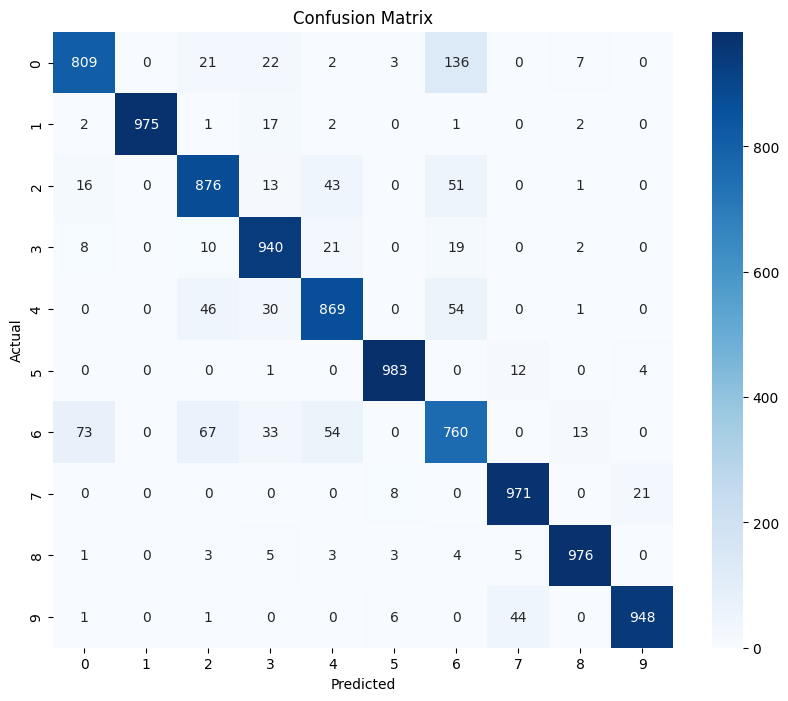

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

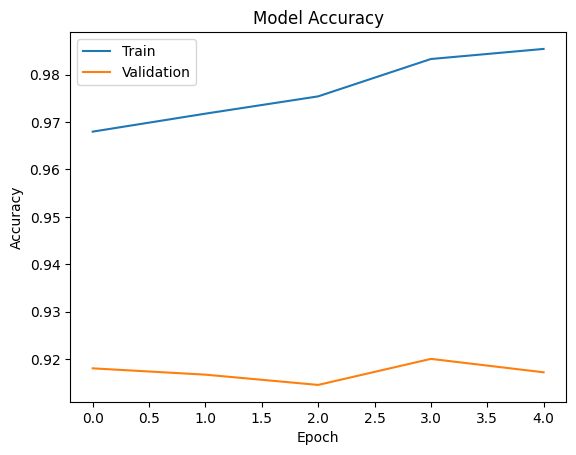

In [24]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

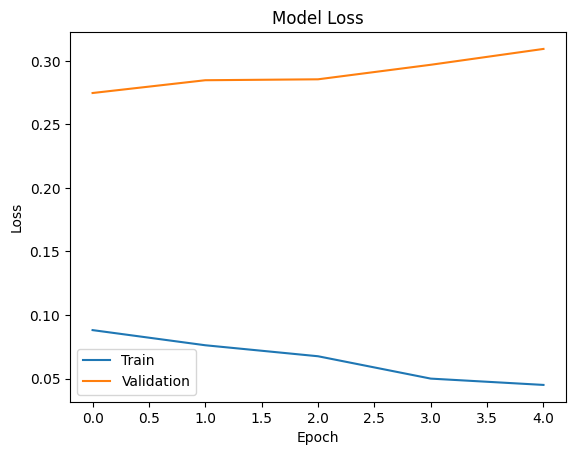

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

Results

Test Accuracy: 91%

The CNN model was trained on the Fashion MNIST dataset.
Callbacks were used to improve training performance and prevent overfitting.
Classification Report and Confusion Matrix were generated to evaluate model performance.
